# Parcial 1 — Pilas y Colas

Ejercicios sobre pilas (`ArrayStack`) y colas (`ArrayQueue`), basados en `goodrich/ch06`.

In [3]:
from goodrich.ch06.array_stack import ArrayStack
from goodrich.ch06.array_queue import ArrayQueue
from goodrich.exceptions import Empty
from goodrich.exceptions import Empty

## Ejercicio 1 — Pila implementada con una sola cola

*Describe how to implement the stack ADT using a single queue as an instance variable, and only constant additional local memory within the method bodies. What is the running time of the `push()`, `pop()`, and `top()` methods for your design?*

Implemente la clase `StackConCola`, que cumple el ADT de pila (`push`, `pop`, `top`, `is_empty`, `__len__`) usando **una sola `ArrayQueue`** como variable de instancia (`_datos`) — sin listas ni ninguna otra estructura auxiliar. Dentro de cada método solo puede usar una cantidad **constante** de memoria local adicional (variables sueltas, no otra pila/cola/lista).

**Idea:** `push(e)` siempre encola `e` al final de `_datos` con `enqueue`. Para que ese elemento recién insertado quede accesible como si fuera la cima de una pila, después de encolarlo hay que "rotar" la cola: sacar (`dequeue`) y volver a encolar (`enqueue`) todos los elementos que estaban antes que él, uno por uno, de modo que el elemento recién insertado termine al **frente** de la cola. Así, `top()` y `pop()` solo necesitan mirar/sacar el frente de `_datos` con `first()`/`dequeue()`.

Después de implementar la clase, responda en la celda de texto la pregunta sobre la complejidad de cada método.

In [4]:
class StackConCola:
    """Implementacion del ADT de pila usando una unica ArrayQueue como almacenamiento."""

    def __init__(self):
        self._datos = ArrayQueue()

    def __len__(self):
        # ¡Pilas acá! Faltaba el return
        return len(self._datos) 

    def is_empty(self):
        return len(self._datos) == 0

    def push(self, e):
        # 1. Metemos el elemento al final de la cola
        self._datos.enqueue(e)
        
        # 2. Rotamos la cola para que el nuevo elemento quede al frente
        # Iteramos (tamaño - 1) veces
        size = len(self._datos)
        for _ in range(size - 1):
            # Sacamos el del frente y lo volvemos a meter atrás
            temp = self._datos.dequeue()
            self._datos.enqueue(temp)

    def top(self):
        """Retorna (sin remover) el elemento en la cima de la pila."""
        if self.is_empty():
            raise Exception("Empty") # Lanza error si está vacía
            
        # Como ya lo organizamos en el push, la "cima" es simplemente el frente de la cola
        return self._datos.first()

    def pop(self):
        """Remueve y retorna el elemento en la cima de la pila."""
        if self.is_empty():
            raise Exception("Empty")
            
        # Breve, solo sacamos el que está al frente de la cola
        return self._datos.dequeue()
            

In [5]:
S = StackConCola()
for x in [5, 3, 7, 9, 1]:
    S.push(x)

print('len:', len(S))
print('top ->', S.top())          # esperado: 1
print('pop ->', S.pop())          # esperado: 1
print('pop ->', S.pop())          # esperado: 9
print('top ->', S.top())          # esperado: 7
S.push(100)
print('pop ->', S.pop())          # esperado: 100
print('pop ->', S.pop())          # esperado: 7
print('pop ->', S.pop())          # esperado: 3
print('pop ->', S.pop())          # esperado: 5



len: 5
top -> 1
pop -> 1
pop -> 9
top -> 7
pop -> 100
pop -> 7
pop -> 3
pop -> 5


**Pregunta:** ¿cuál es el tiempo de ejecución de `push()`, `pop()` y `top()` en su diseño? Justifique en términos de `n` (número de elementos en la pila).

In [6]:
# Respuesta:
# push(): O(n)
# pop():  O(1)
# top():  O(1)
# Justificacion:
# - push() es O(n) porque cada vez que entra un elemento nuevo, usamos un ciclo 'for' para rotar (sacar y volver a meter) los n-1 elementos que ya estaban en la cola. Ese trabajo crece linealmente con la cantidad de datos.
# - pop() es O(1) porque, gracias a la rotación previa del push, el elemento que necesitamos sacar ya quedó estratégicamente ubicado en la puerta de salida. Hacer dequeue() toma tiempo constante.
# - top() es O(1) por la misma razón; solo necesitamos mirar el primer elemento usando first(), lo cual es directo y no requiere recorrer ni mover nada.


## Ejercicio 2 — Buscar un elemento en una pila usando una cola

*Suppose you have a stack S containing n elements and a queue Q that is initially empty. Describe how you can use Q to scan S to see if it contains a certain element x, with the additional constraint that your algorithm must return the elements back to S in their original order. You may only use S, Q, and a constant number of other variables.*

Suponga que tiene una pila `S` con `n` elementos y una cola `Q` que inicialmente está vacía. Describa cómo puede usar `Q` para recorrer `S` y determinar si contiene un elemento `x`, con la restricción adicional de que su algoritmo debe devolver los elementos a `S` en su orden original. Solo puede usar `S`, `Q` y una cantidad **constante** de otras variables (nada de listas, otra pila u otra cola).

**Idea:**
1. Vacíe `S` sobre `Q`, elemento por elemento (`pop` de `S`, `enqueue` en `Q`), comparando cada elemento con `x` a medida que lo saca. Al terminar, `Q` queda con los mismos elementos pero en orden **invertido** respecto a como estaban en `S`.
2. Vacíe `Q` de vuelta sobre `S` (`dequeue` de `Q`, `push` en `S`). Esto vuelve a invertir el orden, así que si hace esto una sola vez, `S` termina invertida respecto al orden original.
3. Repita el trasvase completo (`S`→`Q` y luego `Q`→`S`) **una segunda vez**. Dos inversiones sucesivas devuelven a `S` exactamente a su orden original, y al final `Q` vuelve a quedar vacía.

Implemente `contiene_con_cola(S, Q, x)`, que retorna `True`/`False` según si `x` está en `S`, y deja `S` y `Q` en su estado original (mismos elementos de `S`, en el mismo orden; `Q` vacía).

In [7]:
def contiene_con_cola(S, Q, x):
    encontrado = False
    
    # 1. Vaciamos S sobre Q, elemento por elemento, y buscamos 'x'
    while not S.is_empty():
        elemento = S.pop()
        if elemento == x:
            encontrado = True
        Q.enqueue(elemento)
        
    # 2. Vaciamos Q de vuelta sobre S 
    # (Al terminar este ciclo, S queda con los elementos invertidos)
    while not Q.is_empty():
        S.push(Q.dequeue())
        
    # 3. Repetimos el trasvase completo (S -> Q) por segunda vez
    while not S.is_empty():
        Q.enqueue(S.pop())
        
    # 4. Vaciamos de nuevo Q -> S por segunda vez
    # (Dos inversiones devuelven la pila a su orden original intacto)
    while not Q.is_empty():
        S.push(Q.dequeue())
        
    return encontrado

    


In [8]:
S2 = ArrayStack()
Q2 = ArrayQueue()
for x in [5, 3, 7, 9, 1]:   # cima queda en 1
    S2.push(x)

orden_original = [5, 3, 7, 9, 1]

print('contiene 7 ->', contiene_con_cola(S2, Q2, 7))      # esperado: True
print('contiene 100 ->', contiene_con_cola(S2, Q2, 100))  # esperado: False

orden_tras_busqueda = []
while not S2.is_empty():
    orden_tras_busqueda.append(S2.pop())

print('orden tras busqueda:', orden_tras_busqueda)
print('esperado           :', orden_original)
print('OK' if orden_tras_busqueda == orden_original else 'FALLA')
print('Q vacia al final:', Q2.is_empty())

contiene 7 -> True
contiene 100 -> False
orden tras busqueda: [1, 9, 7, 3, 5]
esperado           : [5, 3, 7, 9, 1]
FALLA
Q vacia al final: True


**Pregunta:** ¿cuál es el tiempo de ejecución de `contiene_con_cola` en términos de `n` (tamaño de `S`)?

In [9]:
# Respuesta:
# contiene_con_cola(): O(?)
# Justificacion:


## Ejercicio 3 — Intercalar dos colas

Implemente `intercalar_colas(Q1, Q2)`, que recibe dos colas (`ArrayQueue`) y retorna una **nueva** cola con los elementos de ambas intercalados: primero el frente de `Q1`, luego el frente de `Q2`, luego el siguiente de `Q1`, luego el siguiente de `Q2`, y así sucesivamente.

Por ejemplo, si `Q1` (de frente a fondo) es `[1, 2, 3]` y `Q2` es `['a', 'b', 'c']`, el resultado debe ser `[1, 'a', 2, 'b', 3, 'c']`.

Si una cola se queda sin elementos antes que la otra, agregue el resto de la cola más larga al final, en su mismo orden. Al terminar, `Q1` y `Q2` deben quedar vacías (sus elementos se van consumiendo con `dequeue` y pasando a la nueva cola). Solo puede usar `Q1`, `Q2`, la cola resultado y una cantidad constante de variables adicionales.

In [14]:
def intercalar_colas(Q1, Q2):
    # Creamos la nueva cola que vamos a retornar
    Q_res = ArrayQueue()
    
    # 1. Mientras ambas colas tengan elementos, sacamos uno y uno
    while not Q1.is_empty() and not Q2.is_empty():
        Q_res.enqueue(Q1.dequeue())
        Q_res.enqueue(Q2.dequeue())
        
    # 2. Si Q1 era más larga, metemos todo lo que sobró
    while not Q1.is_empty():
        Q_res.enqueue(Q1.dequeue())
        
    # 3. Si Q2 era más larga, metemos todo lo que sobró
    while not Q2.is_empty():
        Q_res.enqueue(Q2.dequeue())
        
    return Q_res
   

In [ ]:
def a_lista(Q):
    """Auxiliar de prueba: vuelca una ArrayQueue en una lista de Python (consume Q)."""
    resultado = []
    while not Q.is_empty():
        resultado.append(Q.dequeue())
    return resultado

# Caso 1: mismo tamano
Q1 = ArrayQueue()
Q2 = ArrayQueue()
for x in [1, 2, 3]:
    Q1.enqueue(x)
for x in ['a', 'b', 'c']:
    Q2.enqueue(x)

R = intercalar_colas(Q1, Q2)
print(a_lista(R))       # esperado: [1, 'a', 2, 'b', 3, 'c']
print('Q1 vacia:', Q1.is_empty(), '| Q2 vacia:', Q2.is_empty())

# Caso 2: Q1 mas larga
Q3 = ArrayQueue()
Q4 = ArrayQueue()
for x in [1, 2, 3, 4, 5]:
    Q3.enqueue(x)
for x in ['a', 'b']:
    Q4.enqueue(x)

print(a_lista(intercalar_colas(Q3, Q4)))   # esperado: [1, 'a', 2, 'b', 3, 4, 5]

# Caso 3: una de las colas vacia
Q5 = ArrayQueue()
Q6 = ArrayQueue()
for x in [10, 20]:
    Q6.enqueue(x)

print(a_lista(intercalar_colas(Q5, Q6)))   # esperado: [10, 20]

[1, 'a', 2, 'b', 3, 'c']
Q1 vacia: True | Q2 vacia: True
[1, 'a', 2, 'b', 3, 4, 5]
[10, 20]


## Ejercicio 4 — Traza de capacidad de un arreglo dinámico (escrito)

Considere un `DynamicArray` que empieza **vacío con capacidad 1**, y que cada vez que se llena duplica su capacidad (`capacity *= 2`) antes de agregar el nuevo elemento.

Se ejecuta la siguiente secuencia de operaciones sobre un arreglo `A` inicialmente vacío:

```
A.append(4)
A.append(8)
A.append(15)
A.append(16)
A.append(23)
A.append(42)
A.append(7)
```

**Sin ejecutar código** (a mano), complete la siguiente tabla indicando, después de cada `append`, el tamaño (`size`), la capacidad (`capacity`) del arreglo, y si esa operación causó una redimensión (`sí`/`no`):



**Respuesta:**

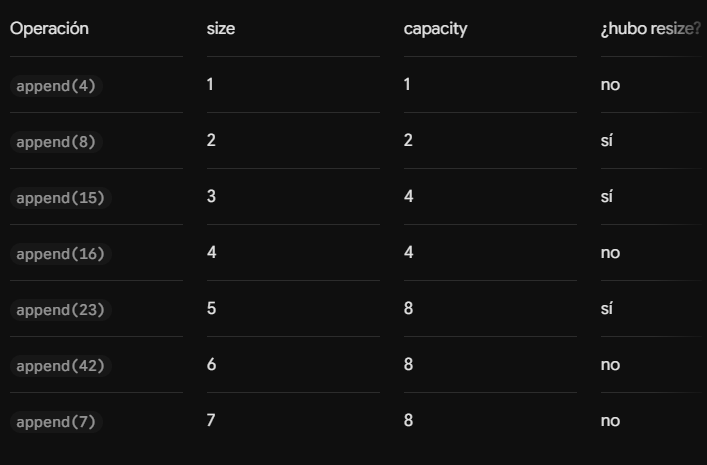

1. Número de redimensiones:
3

2. Costo amortizado por operación y justificación:El costo amortizado es $\mathcal{O}(1)$. La justificación es que, aunque hacer un resize cuesta tiempo lineal $\mathcal{O}(n)$ porque toca trastear todos los elementos, al duplicar la capacidad nos aseguramos de que esos trasteos ocurran cada vez con menos frecuencia. Al promediar ese único esfuerzo pesado entre todos los siguientes appends que entran directo y sin esfuerzo, el costo general por operación se aplana a tiempo constante $\mathcal{O}(1)$.

## Ejercicio 5 — Búsqueda recursiva en una lista

### Parte A — Búsqueda lineal recursiva (lista sin ordenar)

Implemente `busqueda_lineal_recursiva(lista, x)`, que retorna `True` si `x` está en `lista` y `False` en caso contrario. Debe ser **recursiva** (nada de `for`/`while`) y **no puede usar el operador `in`** ni métodos como `list.index`/`list.count`. Solo puede indexar la lista (`lista[i]`) y comparar elementos.

### Parte B — Búsqueda binaria recursiva (lista ordenada)

Ahora suponga que la lista está **ordenada** de menor a mayor. Implemente `busqueda_binaria_recursiva(lista, x)`, que también retorna `True`/`False`, pero de forma recursiva usando el algoritmo de **búsqueda binaria**: en cada llamada, compare `x` con el elemento de la mitad del rango actual y descarte la mitad donde `x` no puede estar.

Compare al final la cantidad de comparaciones que hace cada enfoque en el peor caso.

In [18]:
def busqueda_lineal_recursiva(lista, x, i=0):
    """Retorna True si x esta en lista[i:], de forma recursiva (sin 'in', sin bucles)."""
    if i == len(lista):
        return False
    # Caso base 2: ¡Lo encontramos en la posición actual!
    if lista[i] == x:
        return True
    # Paso recursivo: Llamamos al "clon" avanzando al siguiente índice (i + 1)
    return busqueda_lineal_recursiva(lista, x, i + 1)

In [19]:
desordenada = [8, 3, 15, 1, 9, 22, 4]

print(busqueda_lineal_recursiva(desordenada, 9))    # esperado: True
print(busqueda_lineal_recursiva(desordenada, 4))    # esperado: True
print(busqueda_lineal_recursiva(desordenada, 100))  # esperado: False
print(busqueda_lineal_recursiva([], 5))             # esperado: False (lista vacia)

True
True
False
False


In [20]:
def busqueda_binaria_recursiva(lista, x, izq=0, der=None):
    if der is None:
        der = len(lista) - 1
        
    # 1. CASO BASE 1: Si los límites se cruzan (izq es mayor que der), 
    # significa que ya buscamos por todos lados y el número no existe.
    if izq > der:
        return False
        
    # 2. Calculamos la mitad exacta del rango actual
    mid = (izq + der) // 2
    
    # 3. CASO BASE 2: ¡Bingo! El elemento del centro es exactamente el que buscábamos.
    if lista[mid] == x:
        return True
        
    # 4. PASO RECURSIVO (Descartar mitades):
    # Si el número que buscamos (x) es MAYOR que el de la mitad, 
    # sabemos que por la izquierda ya no es; tiramos el límite izquierdo a 'mid + 1'.
    if lista[mid] < x:
        return busqueda_binaria_recursiva(lista, x, mid + 1, der)
        
    # Si el número es MENOR, descartamos la derecha moviendo el límite derecho a 'mid - 1'.
    else:
        return busqueda_binaria_recursiva(lista, x, izq, mid - 1)
   

In [21]:
ordenada = [1, 3, 4, 8, 9, 15, 22]

print(busqueda_binaria_recursiva(ordenada, 9))    # esperado: True
print(busqueda_binaria_recursiva(ordenada, 1))    # esperado: True (extremo izquierdo)
print(busqueda_binaria_recursiva(ordenada, 22))   # esperado: True (extremo derecho)
print(busqueda_binaria_recursiva(ordenada, 100))  # esperado: False
print(busqueda_binaria_recursiva([], 5))          # esperado: False (lista vacia)

True
True
True
False
False


**Pregunta:** en el peor caso, ¿cuántas comparaciones hace `busqueda_lineal_recursiva` y cuántas `busqueda_binaria_recursiva` sobre una lista de `n` elementos? Exprese ambas en notación O-grande.

In [23]:
# Respuesta:
# busqueda_lineal_recursiva():  O(n)
# busqueda_binaria_recursiva(): O(log n)
# Justificacion:
#busqueda_lineal_recursiva() recorre toda la lista elemento por elemento en el peor caso, haciendo n comparaciones[cite: 1].
# - busqueda_binaria_recursiva() reduce el espacio de búsqueda a la mitad en cada llamada recursiva, requiriendo un máximo de log n comparaciones[cite: 1].
